In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import math 
import matplotlib.ticker as ticker

data = pd.read_csv("healthcare_dataset.csv")


In [6]:
data = pd.read_csv("healthcare_dataset.csv")
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [7]:
data = pd.read_csv("healthcare_dataset.csv")
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
data = pd.read_csv("healthcare_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 12.3 MB


In [9]:
data = pd.read_csv("healthcare_dataset.csv")
data.duplicated().sum()

np.int64(534)

In [10]:
data = pd.read_csv("healthcare_dataset.csv")
Data = data.drop_duplicates()

In [11]:
Data.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


In [12]:
Data.describe(include=object)

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\2727778795.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Data.describe(include=object)


,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27496,6898,9218,50,27,44,11139,18473,53,11038,18437


In [13]:

patient_count = Data["Medical Condition"].value_counts()


In [50]:
Data["Date of Admission"] = pd.to_datetime(Data["Date of Admission"])
Data["Discharge Date"] = pd.to_datetime(Data["Discharge Date"])

Data["length of stay"] = (Data["Discharge Date"] - Data["Date of Admission"]).dt.days

In [15]:
total_billing = Data.groupby("Medical Condition")["Billing Amount"].sum().sort_values(ascending=False)
print(total_billing)


Medical Condition
Diabetes        2.364870e+08
Obesity         2.360067e+08
Arthritis       2.351676e+08
Hypertension    2.333785e+08
Asthma          2.331363e+08
Cancer          2.298922e+08
Name: Billing Amount, dtype: float64


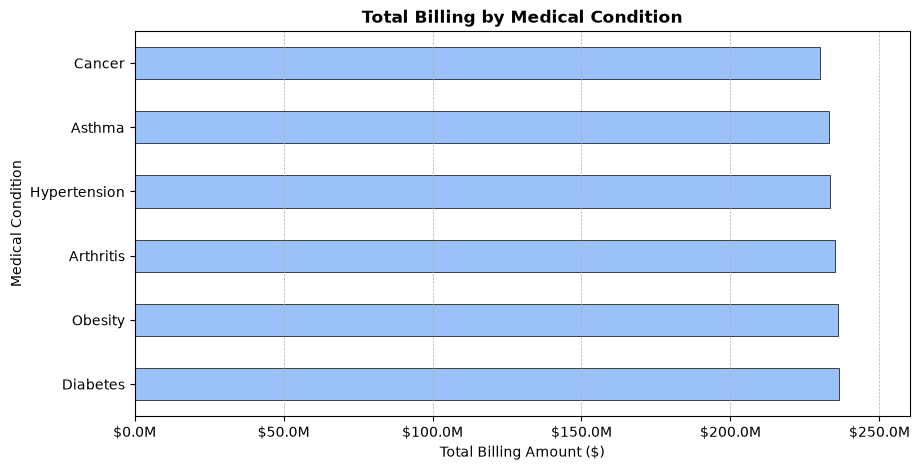

In [16]:
total_billing.plot(
    kind="barh",
    figsize=(10,5),
    edgecolor = "black",
    linewidth = 0.5,
    color = "#9BC2F8"
)

plt.title("Total Billing by Medical Condition",fontsize=12, fontweight="bold")
plt.xlabel("Total Billing Amount ($)")
plt.ylabel("Medical Condition")
plt.grid(axis= "x",linewidth = 0.5 , linestyle = "--")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${x*1e-6:.1f}M")
)

plt.xlim(0, total_billing.max() * 1.1)


plt.show()

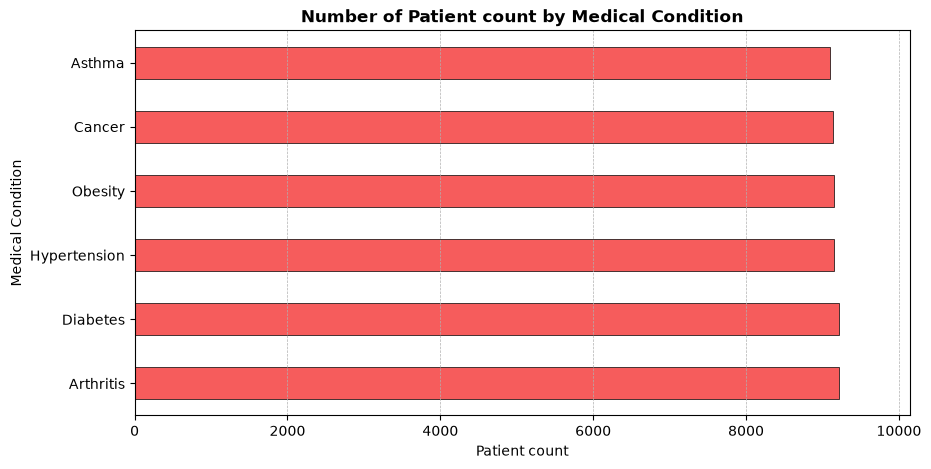

In [17]:
patient_count.plot(
    kind="barh",
    figsize = (10,5),
    edgecolor = "black",
    linewidth = 0.5,
    color = "#F65C5CFF"
)
plt.title("Number of Patient count by Medical Condition",fontsize=12, fontweight="bold")
plt.xlabel("Patient count")
plt.ylabel("Medical Condition")
plt.grid(axis="x" , linestyle = "--" , linewidth = 0.5)

plt.xlim(0,patient_count.max()*1.1)

plt.show()

In [18]:
bins = [0,18,30,45,60,100]
labels = ["0-18" , "19-30", "31-45" , "46-60" , "60+"]

Data["Age group"] = pd.cut(
    Data["Age"],bins=bins , labels=labels
)

age_group = Data["Age group"].value_counts().sort_index(ascending=False)
 

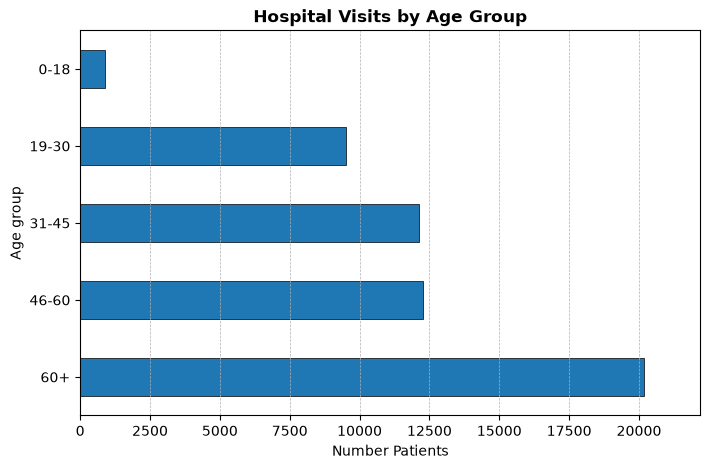

In [19]:
age_group.plot(
    kind="barh",
    figsize=(8,5),
    edgecolor="black",
    linewidth=0.5
)

plt.title("Hospital Visits by Age Group" , fontweight="bold")
plt.xlabel("Number Patients")
plt.grid(axis = "x" , linewidth = 0.5 , linestyle = "--")
plt.xlim(0,age_group.max()*1.1)
plt.show()

In [20]:
gender_bill = Data.groupby("Gender")["Billing Amount"].sum().sort_index(ascending=False)

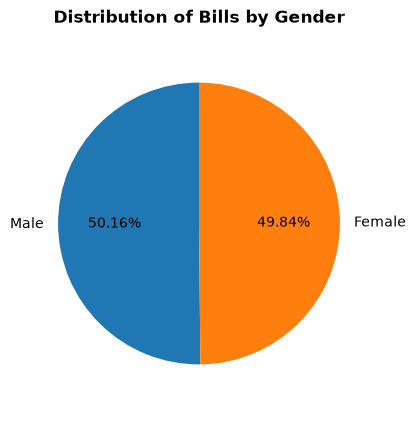

In [21]:
gender_bill.plot(
    kind="pie",
    autopct = "%1.2f%%",
    figsize=(4,5),
    startangle = 90
)
plt.title("Distribution of Bills by Gender", fontweight = "bold")
plt.axis("equal")
plt.show()

In [22]:
doctor = Data["Doctor"].value_counts().head(10)
print(doctor)

Doctor
Michael Smith       27
John Smith          22
Robert Smith        21
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64


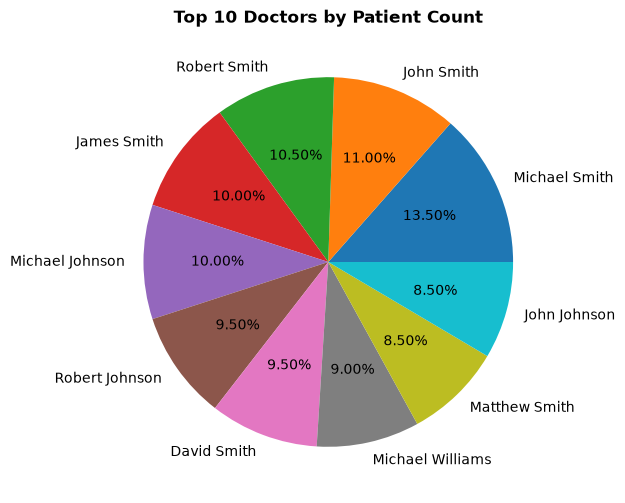

In [23]:
doctor.plot(
    kind = "pie",
    figsize=(10,6),
    autopct ="%1.2f%%"
)
plt.title("Top 10 Doctors by Patient Count" , fontweight = "bold")
plt.show()

In [24]:
hospital = Data.groupby("Hospital")["Billing Amount"].sum().sort_values(ascending=False).head(10)
print(hospital)

Hospital
Johnson PLC    1.081477e+06
LLC Smith      1.030190e+06
Smith PLC      1.029424e+06
Ltd Smith      1.003366e+06
Smith Ltd      9.700359e+05
Johnson Inc    9.343107e+05
Group Smith    9.029758e+05
Inc Brown      8.779613e+05
LLC Johnson    8.164384e+05
Smith Group    8.066313e+05
Name: Billing Amount, dtype: float64


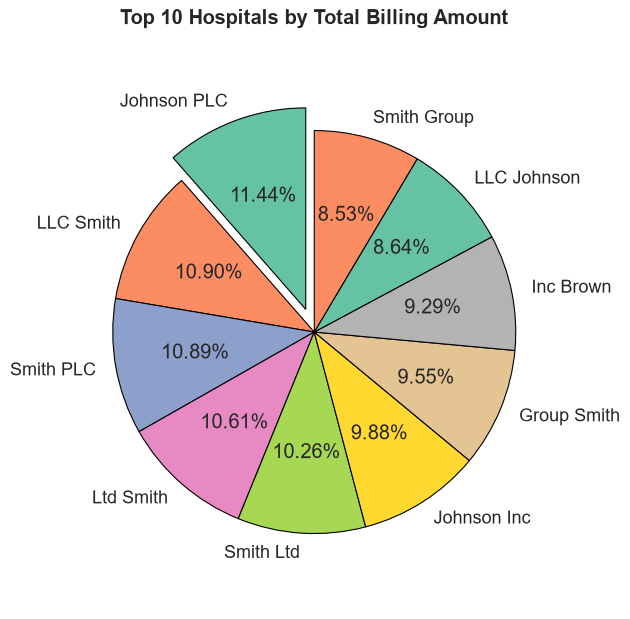

In [ ]:

sns.set(font_scale=1.2)
plt.figure(figsize=(6.5, 6.5))

plt.pie(
    x=hospital.values,
    labels=hospital.index,
    autopct="%1.2f%%",
    colors=sns.color_palette("Set2", len(hospital)),
    startangle=90,
    explode=[0.12] + [0] * (len(hospital) - 1),
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

plt.title("Top 10 Hospitals by Total Billing Amount", fontweight="bold")
plt.axis("equal")  # Makes the pie chart a perfect circle

plt.tight_layout()
plt.show()

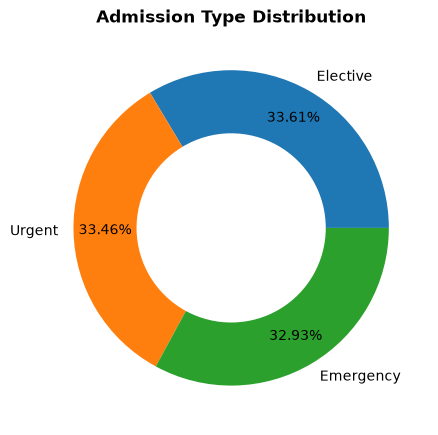

In [ ]:
admission = Data["Admission Type"].value_counts()

plt.figure(figsize=(4.5, 4.5))

plt.pie(
    admission,
    labels=admission.index,
    autopct="%1.2f%%",
    pctdistance=0.8, 
    wedgeprops=dict(width=0.4),
)

plt.title("Admission Type Distribution" , fontweight = "bold")
plt.tight_layout()
plt.show()

In [ ]:
blood = Data["Blood Type"].value_counts()

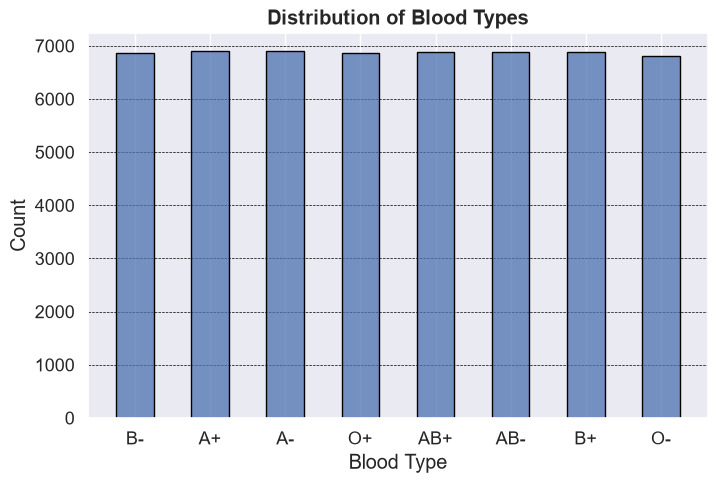

In [48]:

plt.figure(figsize=(8, 5))

sns.histplot(data=Data, x="Blood Type", shrink=0.5, edgecolor="black")

plt.title("Distribution of Blood Types" , fontweight="bold")
plt.xlabel("Blood Type")
plt.ylabel("Count")
plt.grid(axis="y" , linestyle="--" , linewidth=0.5 , color="black")
plt.show()

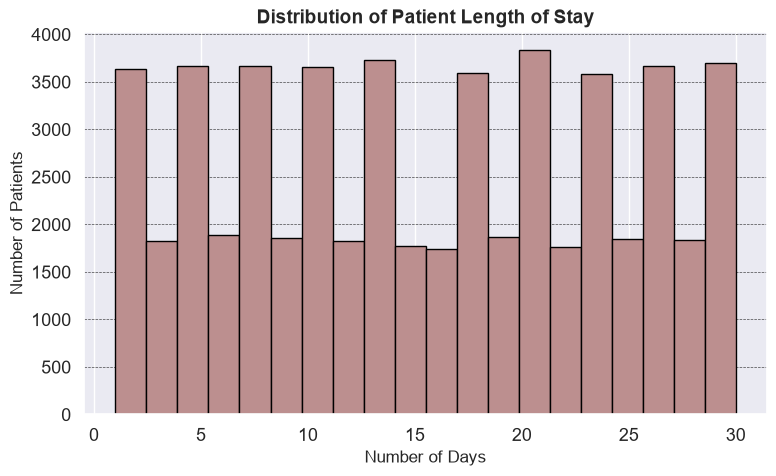

In [85]:
plt.figure(figsize=(8,5))
plt.hist(Data["length of stay"],
         bins=20,
         edgecolor="black",
         color="rosybrown")
plt.title("Distribution of Patient Length of Stay" , fontsize=14 , fontweight="bold")
plt.xlabel("Number of Days" , fontsize=12)
plt.ylabel("Number of Patients" , fontsize=12)
plt.grid(axis="y" , linestyle ="--" , alpha=0.7 , linewidth=0.5 , color="black")
plt.tight_layout()
plt.show()

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\425264993.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


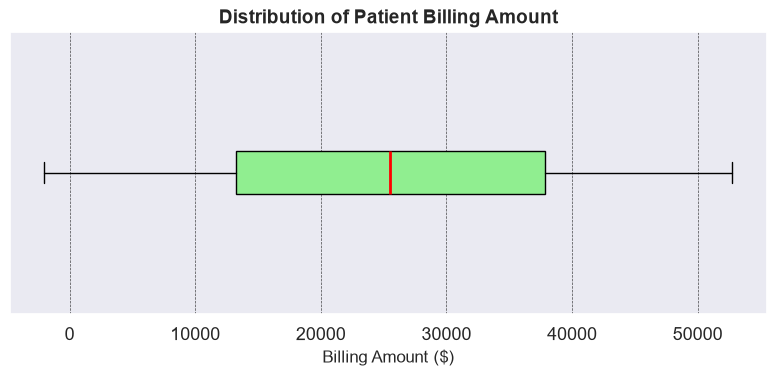

In [90]:

plt.figure(figsize=(8, 4))

plt.boxplot(
    Data["Billing Amount"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen", color="black"),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="orange", alpha=0.7)
)

plt.title("Distribution of Patient Billing Amount", fontsize=14, fontweight="bold")
plt.xlabel("Billing Amount ($)", fontsize=12)

plt.yticks([])

plt.grid(axis="x", linestyle="--", alpha=0.7 , color = "black" , linewidth = 0.5)

plt.tight_layout()  
plt.show()

In [95]:
Data["Date of Admission"] = pd.to_datetime(Data["Date of Admission"])

Data["Month"] = Data["Date of Admission"].dt.month_name()

In [103]:
month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
Data["Month"] = pd.Categorical(Data["Month"], categories=month_order, ordered=True)

billing = Data.groupby("Month")["Billing Amount"].sum()
print(billing)

Month
January      1.197217e+08
February     1.067002e+08
March        1.173555e+08
April        1.136078e+08
May          1.153036e+08
June         1.204837e+08
July         1.214266e+08
August       1.215802e+08
September    1.138440e+08
October      1.200226e+08
November     1.159813e+08
December     1.180410e+08
Name: Billing Amount, dtype: float64


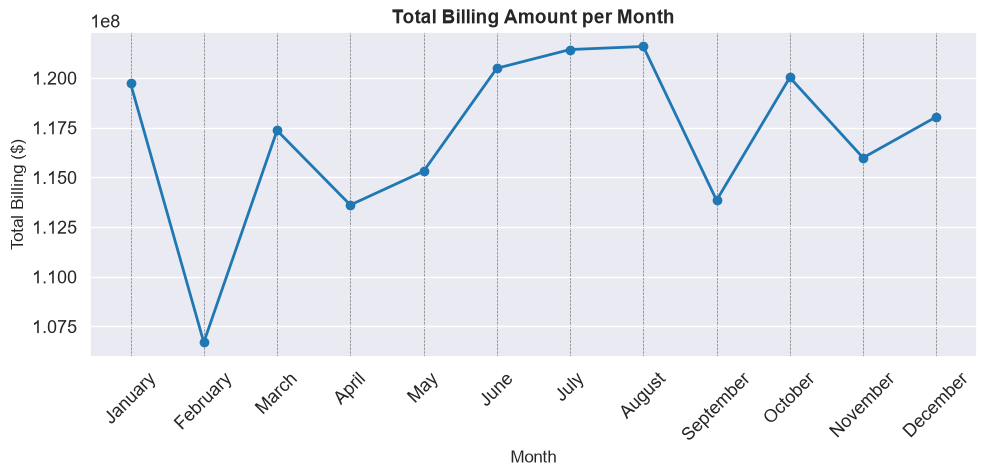

In [117]:
plt.figure(figsize=(10, 5))

billing.plot(
    kind="line",
    marker="o",                
    linewidth=2,
    color="#1f77b4"         
)

plt.title("Total Billing Amount per Month", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Billing ($)", fontsize=12)

plt.xticks(
    ticks=range(len(billing)),
    labels=billing.index,
    rotation=45
)
plt.grid(axis="x", linestyle="--", alpha=0.5 , color="black" , linewidth=0.5)

plt.tight_layout()
plt.show()

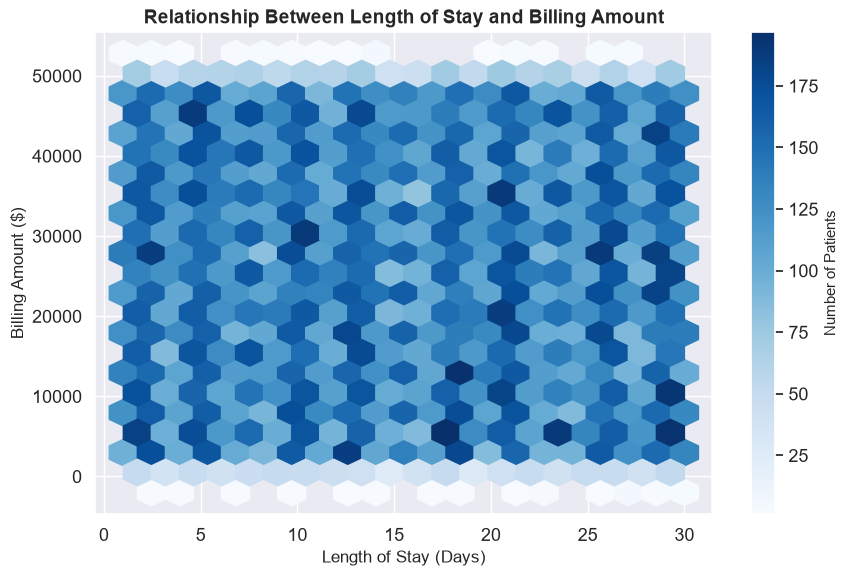

In [125]:
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    Data["length of stay"],
    Data["Billing Amount"],
    gridsize=20,           
    cmap="Blues",          
    mincnt=1               
)

cb = plt.colorbar(hb)
cb.set_label("Number of Patients", fontsize=11)

plt.title("Relationship Between Length of Stay and Billing Amount", fontsize=14, fontweight="bold")
plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Billing Amount ($)", fontsize=12)

plt.tight_layout()
plt.show()